# Calculate optimal depth and block sizes for Kronecker prefix circuits

d = 7.0 s=2.0
d = 5.0 s=2.0
d = 3.0 s=2.0


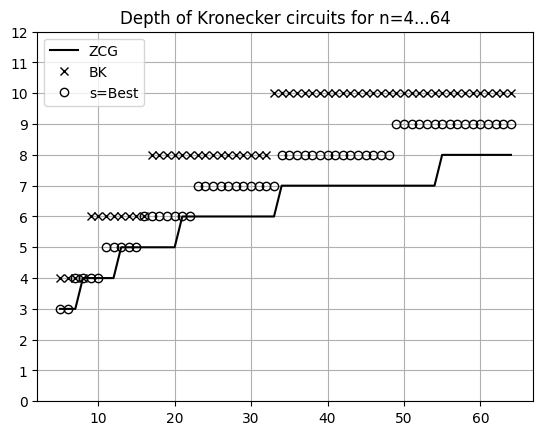

In [29]:
import numpy as np
from matplotlib import pyplot as plt

fibonacci = np.array([1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181, 6765, 10946, 17711])

max_n = 64
n_values = list(range(0,max_n+1))
min_depths = np.zeros((max_n+1,))
min_depths_s_vals = np.zeros((max_n+1,))
min_depths[0] = 0
min_depths[1] = 0
min_depths[2] = 1
min_depths[3] = 2
min_depths[4] = 2
min_depths_s_vals[0] = 0
min_depths_s_vals[1] = 0
min_depths_s_vals[2] = 2
min_depths_s_vals[3] = 2
min_depths_s_vals[4] = 2
opt_depths = np.zeros((max_n+1,))
s2_depths = np.zeros((max_n+1,))
s3_depths = np.zeros((max_n+1,))
bk_depths = np.zeros((max_n+1,))
lbound_depths = np.zeros((max_n+1,))

def get_depth(_n,_s):
    if _n <= _s:
        return _n-1
    else:
        return _s + get_depth(int(np.ceil(_n/_s))-1, _s)


for n in  n_values[5:]:
    this_n_depths = []
    this_s_vals = range(2,int(np.floor(n/2)+1))
    for s in this_s_vals:
        this_n_depths.append(s + min_depths[int(np.ceil(n/s)-1)])
    min_depths[n] = min(this_n_depths)
    min_index = this_n_depths.index(min(this_n_depths))
    min_depths_s_vals[n] = this_s_vals[min_index]
    opt_depths[n] = np.argmax(fibonacci >= n+1) - 3 + 1 # the last +1 is due to indexing
    s2_depths[n] = get_depth(n, 2) # 2*int(np.ceil(np.log2(n))) - 2
    s3_depths[n] = get_depth(n, 3) # 3*int(np.ceil(np.log2(n)/np.log2(3)))-3
    bk_depths[n] = 2*int(np.ceil(np.log2(n)))-2 # 3*int(np.ceil(np.log2(n)/np.log2(3)))-2
    lbound_depths[n] = 3*int(np.ceil(np.log2(n/2)/np.log2(3)))-3
top = max_n+1
# print(f"d = {min_depths[32]} s={min_depths_s_vals[32]}")
# print(f"d = {min_depths[15]} s={min_depths_s_vals[15]}")
# print(f"d = {min_depths[4]} s={min_depths_s_vals[4]}")
print(f"d = {min_depths[24]} s={min_depths_s_vals[24]}")
print(f"d = {min_depths[11]} s={min_depths_s_vals[11]}")
print(f"d = {min_depths[5]} s={min_depths_s_vals[5]}")


colors=[
'black',
'black',
'black',
'#969696',
'#525252',
]

plt.plot(n_values[5:top], opt_depths[5:top],  label='ZCG', linestyle='-', marker='', color=colors[0])#, mfc='none')
plt.plot(n_values[5:top],  bk_depths[5:top], linestyle='', marker='x', label='BK', color=colors[1])
plt.plot(n_values[5:top], min_depths[5:top], linestyle='', marker='o',  mfc='none', label='s=Best', color=colors[2])
# plt.plot(n_values[5:top], s3_depths[5:top], linestyle='', marker='.', label='s=3')
# plt.plot(n_values[5:top], s2_depths[5:top], linestyle='', marker='.', label='s=2', color=colors[3])
# plt.plot(n_values[5:top], bk_depths[5:top]- s3_depths[5:top], label='s=3')
# plt.plot(n_values[5:top], lbound_depths[5:top], linestyle='', marker= 'x', label='lower bound')
plt.yticks(list(range(0,int(np.max(bk_depths))+3)))
plt.title(f'Depth of Kronecker circuits for n=4...{max_n}')
plt.grid(which='both')
plt.legend()


### Calculate for given n the connectivity graph

In [ ]:
n = 64
s = int(min_depths_s_vals[n])
print(s)
print(min_depths[n])

initial_nodes = list(range(n))
connections = []

def get_connections(n, s, nodes, layer=0):
    if n <= 1:
        return layer, []
    if s==0:
        s=1
    print(f'Layer {layer}: {n} {s} {nodes}')
    # Linear layer
    j=0
    connections = []
    k=1
    while j < n-1:
        if j % s != s-1:
            connections.append([nodes[j],nodes[j+1],layer+k])
            k=k+1
        else:
            k=1
        j = j+1
    layer = layer + s -1
    print(f'Layer {layer}: Linear connections {connections}')
    if n <= s:
        return layer, connections

    # Recursive layer
    child_nodes_ids = list(range(s-1, n, s))
    child_nodes = [nodes[ind] for ind in child_nodes_ids]
    child_n = int(np.ceil(n/s)-1)
    child_s = int(min_depths_s_vals[child_n])
    post_recursion_layer, child_connections = get_connections(child_n, child_s, child_nodes, layer=layer)
    connections.extend(child_connections)
    
    # Correction layer
    j=s-1
    layer = post_recursion_layer + 1
    while j < n-1:
        end = min(s, n-j)
        print(f'{n} {s} {j}/{n-1} {end}')
        for k in range(1, end):
            connections.append([nodes[j],nodes[j+k], layer])
        if j + s == n - 1:
            connections.append([nodes[j], nodes[n-1], layer])
        j = j+s
    return layer, connections

depth, edges = get_connections(n, s, initial_nodes)
print(f'Depth: {depth}')
print('Edges:')
for edge in edges:
    print(f'{edge}')
    


2
9.0
Layer 0: 64 2 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63]
Layer 1: Linear connections [[0, 1, 1], [2, 3, 1], [4, 5, 1], [6, 7, 1], [8, 9, 1], [10, 11, 1], [12, 13, 1], [14, 15, 1], [16, 17, 1], [18, 19, 1], [20, 21, 1], [22, 23, 1], [24, 25, 1], [26, 27, 1], [28, 29, 1], [30, 31, 1], [32, 33, 1], [34, 35, 1], [36, 37, 1], [38, 39, 1], [40, 41, 1], [42, 43, 1], [44, 45, 1], [46, 47, 1], [48, 49, 1], [50, 51, 1], [52, 53, 1], [54, 55, 1], [56, 57, 1], [58, 59, 1], [60, 61, 1], [62, 63, 1]]
Layer 1: 31 2 [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45, 47, 49, 51, 53, 55, 57, 59, 61, 63]
Layer 2: Linear connections [[1, 3, 2], [5, 7, 2], [9, 11, 2], [13, 15, 2], [17, 19, 2], [21, 23, 2], [25, 27, 2], [29, 31, 2], [33, 35, 2], [37, 39, 2], [41, 4

### ZCG circuits

In [ ]:
zcg_d6_edges = [
    [0,1,1], # 1
    [2,3,1], # 1
    [4,5,1], # 1
    [6,7,1], # 1
    [8,9,1], # 1
    [10,11,1], # 1
    [12,13,1], # 1
    [14,15,1], # 1
    [16,17,1], # 1
    [18,19,1], # 1
    [20,21,1], # 1
    [23,24,1], # 1
    [27,28,1], # 1
    [1,2,2], # 2
    [1,3,2], # 2
    [5,7,2], # 2
    [9,11,2], # 2
    [13,15,2], # 2
    [17,19,2], # 2
    [21,22,2], # 2
    [24,25,2], # 2
    [28,29,2], # 2
    [3,4,3], # 3
    [3,5,3], # 3
    [3,7,3], # 3
    [11,15,3], # 3
    [19,22,3], # 3
    [25,26,3], # 3
    [29,30,3], # 3
    [5,6,4], # 4
    [7,8,4], # 4
    [7,9,4], # 4
    [7,11,4], # 4
    [7,15,4], # 4
    [22,26,4], # 4
    [30,31,4], # 4
    [9,10,5], # 5
    [11,12,5], # 5
    [11,13,5], # 5
    [15,16,5], # 5
    [15,17,5], # 5
    [15,19,5], # 5
    [15,22,5], # 5
    [15,26,5], # 5
    [31,32,5], # 5
    [13,14,6], # 6
    [17,18,6], # 6
    [19,20,6], # 6
    [19,21,6], # 6
    [22,23,6], # 6
    [22,24,6], # 6
    [22,25,6], # 6
    [26,27,6], # 6
    [26,28,6], # 6
    [26,29,6], # 6
    [26,30,6], # 6
    [26,31,6], # 6
    [26,32,6], # 6
]
zcg_d6_depth = 6

zcg_d6_n32_edges = [edge for edge in zcg_d6_edges if edge[1] != 32]
zcg_d6_n24_edges = [edge for edge in zcg_d6_edges if edge[1] <= 23]
for edge in zcg_d6_n32_edges:
    print(edge)
for edge in zcg_d6_n24_edges:
    print(edge)



[0, 1, 1]
[2, 3, 1]
[4, 5, 1]
[6, 7, 1]
[8, 9, 1]
[10, 11, 1]
[12, 13, 1]
[14, 15, 1]
[16, 17, 1]
[18, 19, 1]
[20, 21, 1]
[23, 24, 1]
[27, 28, 1]
[1, 2, 2]
[1, 3, 2]
[5, 7, 2]
[9, 11, 2]
[13, 15, 2]
[17, 19, 2]
[21, 22, 2]
[24, 25, 2]
[28, 29, 2]
[3, 4, 3]
[3, 5, 3]
[3, 7, 3]
[11, 15, 3]
[19, 22, 3]
[25, 26, 3]
[29, 30, 3]
[5, 6, 4]
[7, 8, 4]
[7, 9, 4]
[7, 11, 4]
[7, 15, 4]
[22, 26, 4]
[30, 31, 4]
[9, 10, 5]
[11, 12, 5]
[11, 13, 5]
[15, 16, 5]
[15, 17, 5]
[15, 19, 5]
[15, 22, 5]
[15, 26, 5]
[13, 14, 6]
[17, 18, 6]
[19, 20, 6]
[19, 21, 6]
[22, 23, 6]
[22, 24, 6]
[22, 25, 6]
[26, 27, 6]
[26, 28, 6]
[26, 29, 6]
[26, 30, 6]
[26, 31, 6]
[0, 1, 1]
[2, 3, 1]
[4, 5, 1]
[6, 7, 1]
[8, 9, 1]
[10, 11, 1]
[12, 13, 1]
[14, 15, 1]
[16, 17, 1]
[18, 19, 1]
[20, 21, 1]
[1, 2, 2]
[1, 3, 2]
[5, 7, 2]
[9, 11, 2]
[13, 15, 2]
[17, 19, 2]
[21, 22, 2]
[3, 4, 3]
[3, 5, 3]
[3, 7, 3]
[11, 15, 3]
[19, 22, 3]
[5, 6, 4]
[7, 8, 4]
[7, 9, 4]
[7, 11, 4]
[7, 15, 4]
[9, 10, 5]
[11, 12, 5]
[11, 13, 5]
[15, 16, 5]
[15, 17,

### Draw circuit

[0, 1, 1]
[2, 3, 1]
[4, 5, 1]
[6, 7, 1]
[8, 9, 1]
[10, 11, 1]
[12, 13, 1]
[14, 15, 1]
[16, 17, 1]
[18, 19, 1]
[20, 21, 1]
[22, 23, 1]
[24, 25, 1]
[26, 27, 1]
[28, 29, 1]
[30, 31, 1]
[32, 33, 1]
[34, 35, 1]
[36, 37, 1]
[38, 39, 1]
[40, 41, 1]
[42, 43, 1]
[44, 45, 1]
[46, 47, 1]
[48, 49, 1]
[50, 51, 1]
[52, 53, 1]
[54, 55, 1]
[56, 57, 1]
[58, 59, 1]
[60, 61, 1]
[62, 63, 1]
[1, 3, 2]
[5, 7, 2]
[9, 11, 2]
[13, 15, 2]
[17, 19, 2]
[21, 23, 2]
[25, 27, 2]
[29, 31, 2]
[33, 35, 2]
[37, 39, 2]
[41, 43, 2]
[45, 47, 2]
[49, 51, 2]
[53, 55, 2]
[57, 59, 2]
[3, 7, 3]
[15, 19, 3]
[27, 31, 3]
[39, 43, 3]
[51, 55, 3]
[7, 11, 4]
[19, 23, 4]
[31, 35, 4]
[43, 47, 4]
[55, 59, 4]
[11, 23, 5]
[35, 47, 5]
[23, 35, 6]
[23, 47, 6]
[11, 15, 7]
[11, 19, 7]
[23, 27, 7]
[23, 31, 7]
[35, 39, 7]
[35, 43, 7]
[47, 51, 7]
[47, 55, 7]
[47, 59, 7]
[3, 5, 8]
[7, 9, 8]
[11, 13, 8]
[15, 17, 8]
[19, 21, 8]
[23, 25, 8]
[27, 29, 8]
[31, 33, 8]
[35, 37, 8]
[39, 41, 8]
[43, 45, 8]
[47, 49, 8]
[51, 53, 8]
[55, 57, 8]
[59, 61, 8]
[1

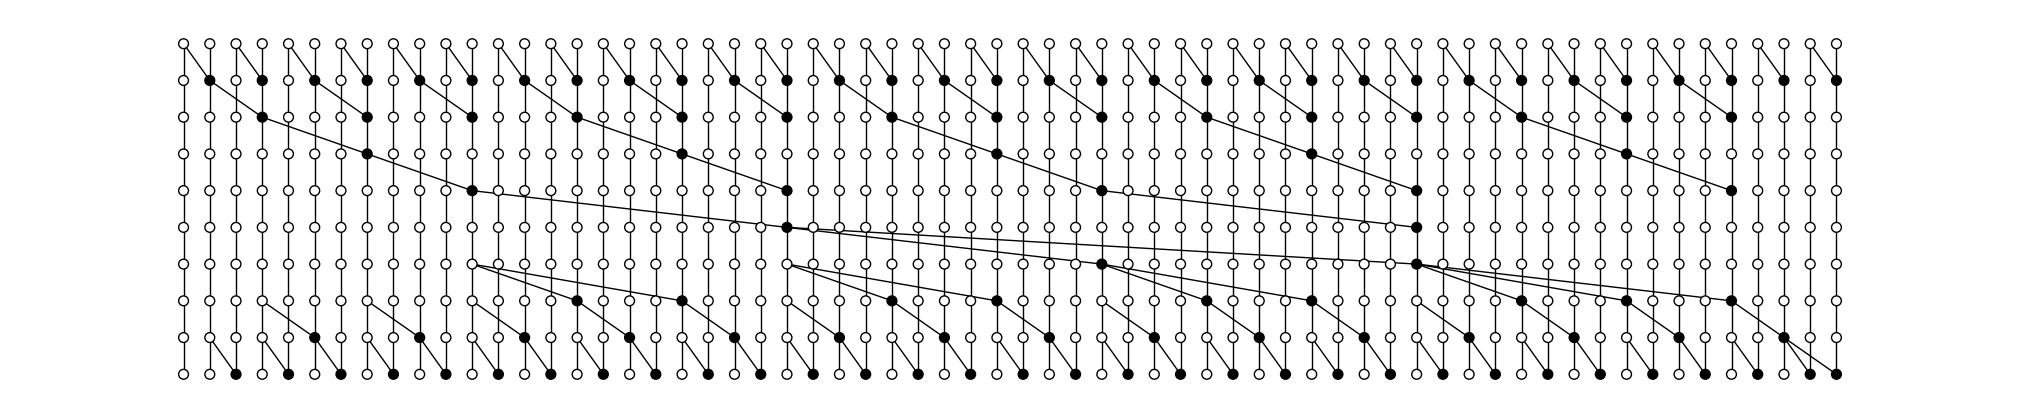

In [ ]:
from matplotlib import pyplot as plt
import networkx as nx

# edges = zcg_d6_n32_edges
# depth = zcg_d6_depth
# print(len(edges))
# n = 32

G = nx.grid_2d_graph(depth+1,n)
node_colors = [['white'] * n for _ in range(depth+1)]
plt.figure(figsize=(20,4))
for d in range(depth+1):
    for i in range(n-1):
        G.remove_edge((d,i),(d,i+1))
    edges_d = [item for item in edges if item[2]==d+1]
    for edge in edges_d:
        print(edge)
        G.add_edge((d,edge[0]),(d+1,edge[1]))
        node_colors[d+1][edge[1]] = 'black'

pos = {(x,y):(y,-x) for x,y in G.nodes()}
nx.draw(G, pos=pos, 
        node_color=sum(node_colors, []),
        edgecolors='black',
        with_labels=False,
        node_size=50)
